In [1]:
# Firstly import all required packages
# enable interactive mode of matplotlib
%matplotlib notebook

# import cv2  # python OpenCV
import os  # 
import numpy as np  # lib for arrays
import datetime
import glob
import pandas as pd

import math as mh  # math package

import matplotlib as mpl  
import matplotlib.pyplot as plt  # namespace for plotting
mpl.rcParams['figure.figsize'] = (6,5)  # change default value of plot size

# matplotlib based package for pretty visualization
import seaborn as sns
plt.style.use('seaborn')
from sklearn.datasets import load_iris
from sklearn.model_selection import KFold, train_test_split

import time
import pickle  # package for dump & load data
import warnings

# <center> Бустинг </center>

*«When in doubt – use xgboost»   
Owen Zhang, top-2 on Kaggle.*

Бустинг - одна из самых сильных идей в машинном обучении за последние 30 лет. 

Идея простая: используя модели, точность которых немногим выше случайного угадывания, построить сильную модель. Тогда можно записать результат работы такого представления:

$$\large f(x) = \sum_{m=1}^{M}\beta_m\,b(x;\gamma_m), $$

$ \beta_m, m=1, \ldots, M $ - коэффициенты для каждой из модели,

$ b(x;\gamma) \in \mathbb{R} $ - функция, характеризуемая параметрами $\gamma$.



Одной из первых реализованных моделей бустинга была модель [AdaBoost.M1](https://web.eecs.utk.edu/~leparker/Courses/CS425-528-fall10/Handouts/AdaBoost.M1.pdf).

<hr style="height:3px"> 

**Алгоритм AdaBoost.M1**

<hr style="height:3px"> 

Опишем её более формально:
1. Инициализируем веса для каждого из примера в выборке $w_i = \dfrac{1}{N}, i = 1,\,2,\ldots, N$.
2. Для m=1 до M:
    a. Обучить классификатор $G_m(x)$ на обучающей выборке используя веса $w_i$.
    b. Вычислить ошибку
    
    $$ \large err_m = \dfrac{\sum_{i=1}^{N} w_i I(y_i \neq G_m(x_i))}{\sum_{i=1}^{N} w_i} $$
    
    c. Вычислить $\large \alpha_m = \log \left( \dfrac{1-err_m}{err_m} \right) $
    
    d. $ \large w_i \leftarrow w_i * exp[\alpha_m * I(y_i \neq G_m(x_i)], i = 1, 2, \ldots, N  $
    
3. Выход:
$$ \large G(x) = sign\left[ \sum_{m=1}^{M} \alpha_m G_m(x) \right] $$

<hr style="height:3px"> 


Рассмотрим функцию ошибки, которую пытается минимизировать классификатор:

$$\large \overline{err} = \dfrac{1}{N} \sum_{i=1}^{N} I (y_i \neq G(x_i)) $$

Цель бустинга оптимизировать эту ошибку, последовательно обучая модель на перевзвешенных данных и добавляя модель к исходному ансамблю. Функция ошибки напрямую не является дифференцируемой. Вместо этого используют некоторую верхнюю оценку, т.е. аппроксимацию этой функции.

Для различных аппроксимаций пороговой функции потерь $[z < 0]$ получаются различные виды бустинга:
- $e^{-z}$ - AdaBoost
- $\log_2(1 + e^{-z})$ - LogitBoost
- $(1 - z)^2$ - GentleBoost
- $e^{-cz(z+a)}$ - BrownBoost
- другие

<IPython.core.display.Javascript object>


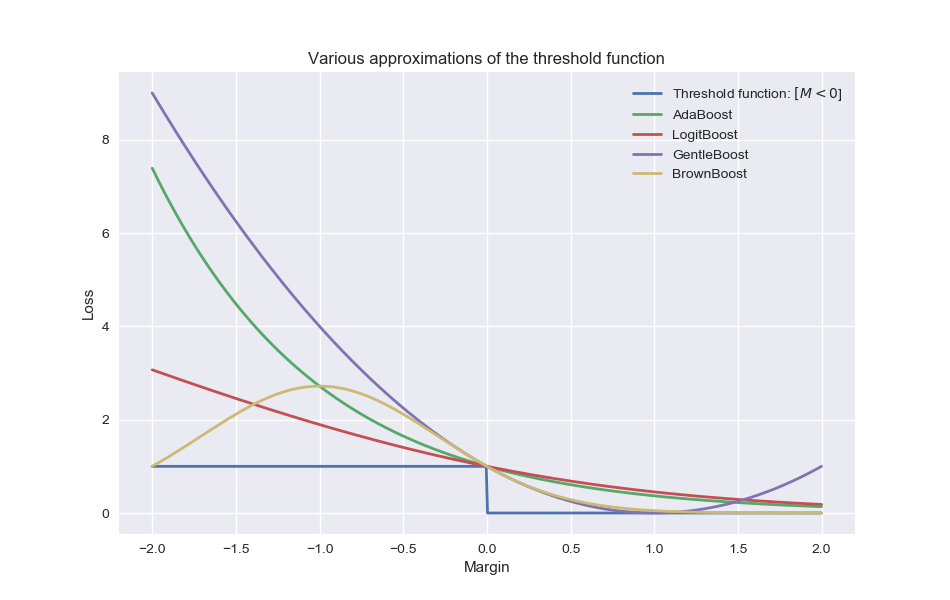

In [5]:
x = np.linspace(-2, 2, 500)

plt.figure(figsize=(9.5,6))
plt.plot(x, x < 0, lw=2, label='Threshold function: $[M < 0$]')
plt.plot(x, np.exp(-x), lw=2, label='AdaBoost')
plt.plot(x, np.log2(1 + np.exp(-x)), lw=2, label='LogitBoost')
plt.plot(x, (1 - x) ** 2, lw=2, label='GentleBoost')
plt.plot(x, np.exp(-x * (x + 2)), lw=2, label='BrownBoost')
plt.title('Various approximations of the threshold function')
plt.legend(loc='best')
plt.xlabel('Margin')
plt.ylabel('Loss');

Проиллюстрируем пример работы AdaBoost на игрушечном примере с использованием деревьев решений:

<img src="images/adaboost.png">

Алгоритм бустинга в общем смысле пытается минимизировать некоторую функцию потерь, определяемую в общем случае выражением:

$$ \Large \min_{\{\beta_m, \gamma_m\}_1^M} \sum_{i=1}^{N} L \left( y_i, \sum_{m=1}^{M} \beta_m b(x_i;\gamma_m) \right) $$.

Но для многих функций потерь оптимизация по параметрам модели для всех моделей композиции является вычислительно затратной, поэтому вместо общей функции потерь используют оптимизацию функции с моделью при её добавлении:

$$ \Large \min_{\beta, \gamma} \sum_{i=1}^{N} L \left( y_i, \beta b(x_i; \, \gamma) \right) $$.

В таком случае алгоритм бустинга описывает последовательно добавление функций с оптимизируемыми параметрами к ансамблю моделей с фиксированными параметрами:

<hr style="height:3px"> 

**Алгоритм Forward Stagewise Additive Modeling**

<hr style="height:3px"> 

1. Инициализиурем функцию $f_0(x) = 0$
2. Для $m = 1, ..., \ldots M$:

    a. Вычислить:
    
    $$\Large (\beta_m, \gamma_m) = \arg \, \min_{\beta, \gamma} \sum_{i=1}^{N} L(y_i, f_{m-1} (x_i) + \beta\,b(x_i, \gamma)) $$.
    
    b. Присвоить:
    $$ \Large f_m(x) = f_{m-1}(x) + \beta_m b(x; \gamma_m) $$

<hr style="height:3px"> 

Для квадратичной функции потерь $ L(y, f(x)) = (y-f(x))^2 $:

$$\Large L(y_i, f_{m-1}(x_i) + \beta\,b(x_i, \gamma)) = (y_i - f_{m-1}(x_i) - \beta\, b(x_i; \gamma))^2 = (r_{im} - \beta\,b(x_i;\gamma))^2 $$,

$ r_{im} = y_i - f_{m-1}(x_i) $ - остатки, то есть разница между текущим ансамблем и $i$-м наблюдением

<img src="images/adaboost.gif">

Плюсы бустинга:
* обучаемые бустингом модели в большинстве случаев превосходят другие методы обучения;
* интерпретируемые результаты - возможно оценить качество признаков;
* возможность работы с немасштабированными данными - бустинг не чувствителен к монотонным преобразованиям входных данных;
* высокая скорость обучения;
* работает с разными видами признаков: числовые и категориальные;
* устойчивы к выбросам входных данных;
* позволяет находить нелинейные зависимости и зависимости высоких порядков во входных данных;
* масштабируются на большие данные;
* реализации бустинга позволяют распараллеливать вычисления как на CPU, так и на GPU (CatBoost).
* богатые возможности подбора параметров: параметры деревьев, задание функции потерь, регуляризации.

Недостатки бустинга:
* склонен выбирать признаки с большей дискретизацией;
* может оверфитнуться на признаках с большим количеством категорий;
* обладает большим `разбросом` (`variance`);
* предсказания не являются гладкой функцией - свойства деревьев;
* ограниченный потенциал в обобщающей способности.  

Существует несколько наиболее распространённых реализаций градиентного бустинга: **XGBoost**, **LightGBM**, **CatBoost**.

Преимущества **XGBoost**:
* богатая история на Kaggle: победители многих соревнований - большое количество примеров применения

Недостатки **XGBoost**:
* написан сообществом - не позволяет максимально поддерживать возможности CPU и GPU при обучении, для больших объемов данных возможны вылеты при обучении

Преимущества **LightGBM**:
* написан в Microsoft и работает в среднем быстрее **XGBoost**

Преимущества **CatBoost**:
* обладает реализациями с хорошей параллелизацией вычислений на GPU;
* позволяет работать с категориальными признаками из коробки.

**Обучим модель XGBoost Regressor на данных по предсказанию цены**

Посмотрим на данные еще раз, чтобы убедиться в их правильности:

In [2]:
df = pd.read_csv('./datasets/kc_house_data.csv', index_col = 0)
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,,,,,,,,,,,,,,,,,,,,
7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
y =  df['price']
X = df.drop(['price', 'date'], axis=1) 

In [4]:
y[:5]

id
7129300520    221900.0
6414100192    538000.0
5631500400    180000.0
2487200875    604000.0
1954400510    510000.0
Name: price, dtype: float64

[Поделим](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) выборку на обучающую и тестовую в соотношении 70/30:

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=17)

In [6]:
X_train

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,,,,,,,,,,,,,,,,,,
2767601280,6,3.75,3160,5000,2.0,0,0,3,8,3160,0,1989,0,98107,47.6748,-122.384,1740,5000
7986400360,5,1.50,2160,5000,1.5,0,2,4,8,2160,0,1926,0,98107,47.6645,-122.360,1450,4265
6450304630,2,1.00,810,5100,1.0,0,0,3,6,810,0,1955,0,98133,47.7317,-122.343,1500,5100
7856000110,3,2.50,2750,10000,1.0,0,3,3,8,1650,1100,1967,0,98006,47.5644,-122.153,2490,10000
8682320420,2,2.50,2170,6361,1.0,0,2,3,8,2170,0,2009,0,98053,47.7109,-122.017,2310,7419
5700002165,2,1.00,1840,4322,1.0,0,0,4,7,1160,680,1914,0,98144,47.5764,-122.289,1750,4322
3343301490,5,3.50,4790,12957,2.0,0,1,3,9,3110,1680,2005,0,98006,47.5469,-122.194,2620,13538
8078570460,4,2.50,1850,7199,2.0,0,0,4,7,1850,0,1989,0,98031,47.4031,-122.172,1940,7432
1777500160,5,3.00,3070,9804,1.0,0,0,4,9,1740,1330,1968,0,98006,47.5702,-122.128,2550,9689


Импортируем xgboost

Импортируем XGBoost модель из библиотеки. Существует несколько вариантов использования XGBoost: на Python распространены [обёртка](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) под библиотеку Scikit-Learn и исходный интерфейс к XGBoost.

In [7]:
import xgboost as xgb

In [13]:
params = {
    'objective': 'reg:linear',
    'max_depth': 4,
    'learning_rate': 0.1,
    'silent': True,
    'subsample': 0.3,
}
early_stopping_rounds = 50
num_rounds = 10000

In [14]:
xgb_model = xgb.XGBRegressor(**params)

In [15]:
# use native interface
dtrain = xgb.DMatrix(X_train, y_train)
dtest = xgb.DMatrix(X_test, y_test)

In [16]:
# see error for train and test examples due training
watchlist  = [(dtest,'test'), (dtrain,'train')]

In [18]:
np.log(120000)

11.695247021764184

In [17]:
xgb_model = xgb.train(params, dtrain, num_rounds, watchlist, early_stopping_rounds=early_stopping_rounds)

[0]	test-rmse:607847	train-rmse:591295
Multiple eval metrics have been passed: 'train-rmse' will be used for early stopping.

Will train until train-rmse hasn't improved in 50 rounds.
[1]	test-rmse:555244	train-rmse:538955
[2]	test-rmse:508242	train-rmse:492885
[3]	test-rmse:468184	train-rmse:452563
[4]	test-rmse:431910	train-rmse:417078
[5]	test-rmse:398675	train-rmse:384471
[6]	test-rmse:368599	train-rmse:355116
[7]	test-rmse:342592	train-rmse:329091
[8]	test-rmse:318799	train-rmse:306201
[9]	test-rmse:297031	train-rmse:285299
[10]	test-rmse:279067	train-rmse:267078
[11]	test-rmse:261962	train-rmse:251249
[12]	test-rmse:247948	train-rmse:237377
[13]	test-rmse:234744	train-rmse:224672
[14]	test-rmse:224858	train-rmse:214427
[15]	test-rmse:215501	train-rmse:204846
[16]	test-rmse:206601	train-rmse:196335
[17]	test-rmse:199224	train-rmse:188355
[18]	test-rmse:193439	train-rmse:181650
[19]	test-rmse:188376	train-rmse:176103
[20]	test-rmse:182446	train-rmse:170071
[21]	test-rmse:177259	tra

[199]	test-rmse:128989	train-rmse:98307.4
[200]	test-rmse:128995	train-rmse:98201.4
[201]	test-rmse:128859	train-rmse:98015.3
[202]	test-rmse:128881	train-rmse:97953
[203]	test-rmse:128903	train-rmse:97884.2
[204]	test-rmse:129115	train-rmse:97737.5
[205]	test-rmse:129188	train-rmse:97669.1
[206]	test-rmse:129036	train-rmse:97503.9
[207]	test-rmse:128963	train-rmse:97477.4
[208]	test-rmse:128835	train-rmse:97418.6
[209]	test-rmse:128761	train-rmse:97370
[210]	test-rmse:128546	train-rmse:97061.5
[211]	test-rmse:128596	train-rmse:96959.6
[212]	test-rmse:128531	train-rmse:96806.7
[213]	test-rmse:128504	train-rmse:96736.1
[214]	test-rmse:128577	train-rmse:96653.1
[215]	test-rmse:128579	train-rmse:96562.2
[216]	test-rmse:128575	train-rmse:96453.4
[217]	test-rmse:128629	train-rmse:96432.4
[218]	test-rmse:128727	train-rmse:96305.3
[219]	test-rmse:128760	train-rmse:96249
[220]	test-rmse:128694	train-rmse:96115.9
[221]	test-rmse:128597	train-rmse:96070.8
[222]	test-rmse:128619	train-rmse:95968.

[395]	test-rmse:124853	train-rmse:83003.3
[396]	test-rmse:124896	train-rmse:82934.6
[397]	test-rmse:124804	train-rmse:82869.8
[398]	test-rmse:124844	train-rmse:82849.7
[399]	test-rmse:124764	train-rmse:82735.5
[400]	test-rmse:124822	train-rmse:82662
[401]	test-rmse:124802	train-rmse:82613.3
[402]	test-rmse:124794	train-rmse:82571
[403]	test-rmse:124759	train-rmse:82542.8
[404]	test-rmse:124736	train-rmse:82447.2
[405]	test-rmse:124729	train-rmse:82427.8
[406]	test-rmse:124741	train-rmse:82382
[407]	test-rmse:124607	train-rmse:82293.3
[408]	test-rmse:124666	train-rmse:82258.8
[409]	test-rmse:124682	train-rmse:82240.2
[410]	test-rmse:124653	train-rmse:82201.9
[411]	test-rmse:124742	train-rmse:82136.4
[412]	test-rmse:124674	train-rmse:82106.2
[413]	test-rmse:124705	train-rmse:82063.7
[414]	test-rmse:124635	train-rmse:81961.4
[415]	test-rmse:124584	train-rmse:81883
[416]	test-rmse:124627	train-rmse:81830.4
[417]	test-rmse:124640	train-rmse:81799.2
[418]	test-rmse:124698	train-rmse:81766.3


[591]	test-rmse:123519	train-rmse:74861.6
[592]	test-rmse:123520	train-rmse:74821.2
[593]	test-rmse:123491	train-rmse:74798.4
[594]	test-rmse:123463	train-rmse:74767.6
[595]	test-rmse:123442	train-rmse:74748.5
[596]	test-rmse:123507	train-rmse:74681.1
[597]	test-rmse:123521	train-rmse:74650.8
[598]	test-rmse:123560	train-rmse:74612
[599]	test-rmse:123491	train-rmse:74579.4
[600]	test-rmse:123500	train-rmse:74559.6
[601]	test-rmse:123480	train-rmse:74540
[602]	test-rmse:123475	train-rmse:74498.3
[603]	test-rmse:123484	train-rmse:74472
[604]	test-rmse:123396	train-rmse:74439.1
[605]	test-rmse:123444	train-rmse:74408.9
[606]	test-rmse:123483	train-rmse:74377.4
[607]	test-rmse:123452	train-rmse:74349.7
[608]	test-rmse:123450	train-rmse:74286.8
[609]	test-rmse:123427	train-rmse:74255.6
[610]	test-rmse:123379	train-rmse:74182.5
[611]	test-rmse:123412	train-rmse:74151.6
[612]	test-rmse:123363	train-rmse:74112.7
[613]	test-rmse:123294	train-rmse:74091
[614]	test-rmse:123256	train-rmse:73997.6


[787]	test-rmse:122804	train-rmse:68558.5
[788]	test-rmse:122800	train-rmse:68534.7
[789]	test-rmse:122787	train-rmse:68512.9
[790]	test-rmse:122761	train-rmse:68495.7
[791]	test-rmse:122757	train-rmse:68475.8
[792]	test-rmse:122723	train-rmse:68444.2
[793]	test-rmse:122669	train-rmse:68413.4
[794]	test-rmse:122672	train-rmse:68373
[795]	test-rmse:122612	train-rmse:68352.5
[796]	test-rmse:122595	train-rmse:68305.2
[797]	test-rmse:122650	train-rmse:68284.5
[798]	test-rmse:122661	train-rmse:68267.4
[799]	test-rmse:122684	train-rmse:68225.2
[800]	test-rmse:122622	train-rmse:68167.1
[801]	test-rmse:122615	train-rmse:68138.8
[802]	test-rmse:122552	train-rmse:68102.9
[803]	test-rmse:122536	train-rmse:68049
[804]	test-rmse:122542	train-rmse:68015.8
[805]	test-rmse:122537	train-rmse:67994.5
[806]	test-rmse:122504	train-rmse:67964.9
[807]	test-rmse:122489	train-rmse:67945.1
[808]	test-rmse:122448	train-rmse:67918
[809]	test-rmse:122458	train-rmse:67847.1
[810]	test-rmse:122419	train-rmse:67802.

...

[2328]	test-rmse:121873	train-rmse:44192.1
[2329]	test-rmse:121873	train-rmse:44182.6
[2330]	test-rmse:121880	train-rmse:44179.1
[2331]	test-rmse:121882	train-rmse:44175.6
[2332]	test-rmse:121900	train-rmse:44164.9
[2333]	test-rmse:121926	train-rmse:44153.7
[2334]	test-rmse:121913	train-rmse:44148.6
[2335]	test-rmse:121920	train-rmse:44134.3
[2336]	test-rmse:121905	train-rmse:44123.4
[2337]	test-rmse:121909	train-rmse:44115.3
[2338]	test-rmse:121915	train-rmse:44104.6
[2339]	test-rmse:121910	train-rmse:44086.1
[2340]	test-rmse:121903	train-rmse:44080.2
[2341]	test-rmse:121895	train-rmse:44065.8
[2342]	test-rmse:121907	train-rmse:44052.3
[2343]	test-rmse:121910	train-rmse:44048.5
[2344]	test-rmse:121910	train-rmse:44036
[2345]	test-rmse:121907	train-rmse:44023.1
[2346]	test-rmse:121936	train-rmse:44020.1
[2347]	test-rmse:121914	train-rmse:43998
[2348]	test-rmse:121913	train-rmse:43995.2
[2349]	test-rmse:121919	train-rmse:43981.4
[2350]	test-rmse:121903	train-rmse:43975.9
[2351]	test-rms

[2520]	test-rmse:122113	train-rmse:42416.3
[2521]	test-rmse:122104	train-rmse:42402.1
[2522]	test-rmse:122095	train-rmse:42388.5
[2523]	test-rmse:122106	train-rmse:42372.6
[2524]	test-rmse:122100	train-rmse:42366.7
[2525]	test-rmse:122094	train-rmse:42357.6
[2526]	test-rmse:122093	train-rmse:42345.3
[2527]	test-rmse:122098	train-rmse:42337.5
[2528]	test-rmse:122106	train-rmse:42323.2
[2529]	test-rmse:122109	train-rmse:42310.7
[2530]	test-rmse:122124	train-rmse:42306.7
[2531]	test-rmse:122136	train-rmse:42302.9
[2532]	test-rmse:122131	train-rmse:42295.3
[2533]	test-rmse:122130	train-rmse:42287.9
[2534]	test-rmse:122148	train-rmse:42282.7
[2535]	test-rmse:122143	train-rmse:42279.5
[2536]	test-rmse:122132	train-rmse:42278.5
[2537]	test-rmse:122129	train-rmse:42267.7
[2538]	test-rmse:122127	train-rmse:42262.2
[2539]	test-rmse:122130	train-rmse:42257.2
[2540]	test-rmse:122140	train-rmse:42253
[2541]	test-rmse:122155	train-rmse:42245.9
[2542]	test-rmse:122157	train-rmse:42240
[2543]	test-rms

[2712]	test-rmse:122220	train-rmse:40813.9
[2713]	test-rmse:122222	train-rmse:40809.4
[2714]	test-rmse:122228	train-rmse:40800.4
[2715]	test-rmse:122223	train-rmse:40793.4
[2716]	test-rmse:122217	train-rmse:40785.5
[2717]	test-rmse:122223	train-rmse:40774.8
[2718]	test-rmse:122222	train-rmse:40767
[2719]	test-rmse:122215	train-rmse:40758.2
[2720]	test-rmse:122197	train-rmse:40746.2
[2721]	test-rmse:122215	train-rmse:40742.6
[2722]	test-rmse:122218	train-rmse:40740.4
[2723]	test-rmse:122210	train-rmse:40736.1
[2724]	test-rmse:122188	train-rmse:40728
[2725]	test-rmse:122179	train-rmse:40709
[2726]	test-rmse:122185	train-rmse:40702.4
[2727]	test-rmse:122178	train-rmse:40693.8
[2728]	test-rmse:122175	train-rmse:40693.7
[2729]	test-rmse:122185	train-rmse:40692
[2730]	test-rmse:122189	train-rmse:40682.7
[2731]	test-rmse:122171	train-rmse:40673.3
[2732]	test-rmse:122164	train-rmse:40665
[2733]	test-rmse:122168	train-rmse:40660.9
[2734]	test-rmse:122142	train-rmse:40650.8
[2735]	test-rmse:1221

[2904]	test-rmse:122082	train-rmse:39364.9
[2905]	test-rmse:122081	train-rmse:39359.2
[2906]	test-rmse:122086	train-rmse:39349.9
[2907]	test-rmse:122085	train-rmse:39341.3
[2908]	test-rmse:122073	train-rmse:39332
[2909]	test-rmse:122086	train-rmse:39325.3
[2910]	test-rmse:122098	train-rmse:39311.6
[2911]	test-rmse:122094	train-rmse:39303.6
[2912]	test-rmse:122093	train-rmse:39299.3
[2913]	test-rmse:122100	train-rmse:39294.2
[2914]	test-rmse:122128	train-rmse:39281.4
[2915]	test-rmse:122131	train-rmse:39274.9
[2916]	test-rmse:122146	train-rmse:39269.5
[2917]	test-rmse:122158	train-rmse:39264.4
[2918]	test-rmse:122151	train-rmse:39257.4
[2919]	test-rmse:122155	train-rmse:39254.1
[2920]	test-rmse:122160	train-rmse:39249.2
[2921]	test-rmse:122173	train-rmse:39245.3
[2922]	test-rmse:122197	train-rmse:39239.6
[2923]	test-rmse:122194	train-rmse:39230.2
[2924]	test-rmse:122202	train-rmse:39221.3
[2925]	test-rmse:122202	train-rmse:39214.9
[2926]	test-rmse:122209	train-rmse:39206.5
[2927]	test-r

KeyboardInterrupt: 

In [58]:
predict_vals = xgb_model.predict(dtest)

In [59]:
predict_vals

array([591557.5 , 429077.1 , 400619.25, ..., 563142.06, 634846.44,
       523162.88], dtype=float32)

In [60]:
from sklearn.metrics import mean_squared_error

In [62]:
np.sqrt(mean_squared_error(predict_vals, y_test))

132834.30311159737

<IPython.core.display.Javascript object>


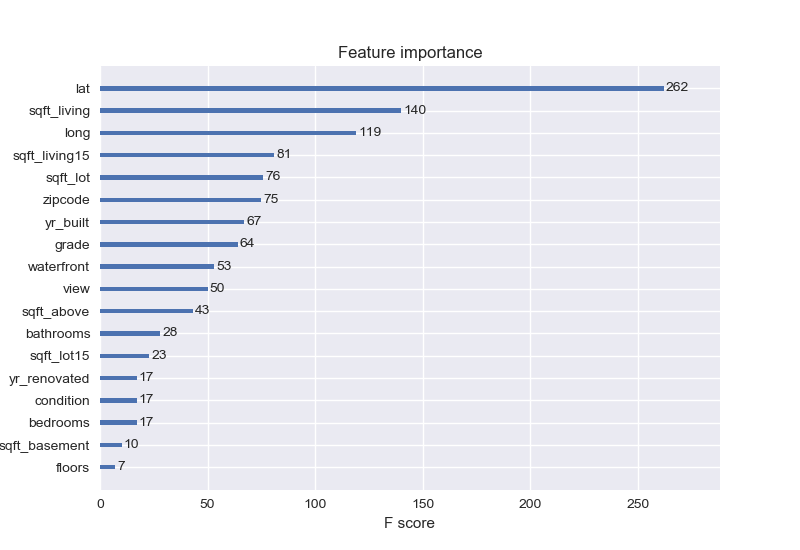

In [63]:
xgb.plot_importance(xgb_model);

[XGBoost параметры](https://xgboost.readthedocs.io/en/latest/):

Выделяют три группы параметров:
- Общие параметры, отвечающие за базовый алгоритм для бустинга и распараллеливание.
- Параметры выбранного базового алгоритма.
- Параметры обучения, отвечающие за функцию потерь и метрику качества на валидации.

**1. Общие параметры:**
- booster [default=gbtree] - тип базового алгоритма для бустинга: дерево решений gbtree или линейная модель gblinear. 
- silent [default=0] - выдавать (silent=0) или нет (silent=1) сообщения по ходу работы алгоритма.
- nthread [default to maximum number of threads available if not set] - число нитей доступных для параллельной работы xgboost.

**2. Параметры базового алгоритма:**

**2.1. Дерево решений:**
- eta [default=0.3] - темп обучения, перед добавлением дерева в композицию оно умножается на eta. Используется для предотвращения переобучения за счёт "сокращения" весов базовых алгоритмов, делая модель более консервативной. Чем меньше eta, тем больше нужно итераций num_boost_round для обучения модели с хорошим качеством. Диапазон: [0, 1]
- gamma [default=0] - минимальное снижение значения функции потерь, необходимое для дальнейшего разбиения вершины дерева. Большие значения gamma > 0 приводят к более консервативным моделям. Диапазон: [0, $\infty$).
- max_depth [default=6] - максимальная глубина дерева. Диапазон: [1, $\infty$). 
- min_child_weight [default=1] - минимальное необходимое (взвешенное) число примеров в каждой вершине. Чем больше, тем более консервативна итоговая модель. Диапазон: [0, $\infty$).
- max_delta_step [default=0] - обычно равен нулю. Положительные значения используются при несбалансированных классах для ускорения сходимости. Диапазон [0, $\infty$).
- subsample [default=1] - доля выборки, используемая для обучения каждого дерева. Если subsample < 1, то выбирается случайная подвыборка, что помогает в борьбе с переобучением. Диапазон: (0, 1]
- colsample_bytree [default=1] - доля признаков, используемая для обучения каждого дерева. Диапазон: (0, 1]
- lambda [default=1] - коэффициент перед $L_2$-регуляризатором в функции потерь.
- alpha [default=0] - коэффициент перед $L_1$-регуляризатором в функции потерь.

**2.2. Линейная модель:**
- lambda [default=0] - коэффициент перед $L_2$-регуляризатором вектора весов в функции потерь.
- alpha [default=0] - коэффициент перед $L_1$-регуляризатором вектора весов в функции потерь.
- lambda_bias [default=0] - коэффициент перед $L_2$-регуляризатором смещения (свободного члена) в функции потерь.

**3. Параметры задачи обучения:**
- objective [default=reg:linear] - используемая при обучении функция потерь:
    - "reg:linear" – линейная регрессия.
    - "reg:logistic" – логистическая регрессия.
    - "binary:logistic" – логистическая регрессия для бинарной классификации, на выходе - вероятность.
    - "binary:logitraw" – то же самое, но на выходе - значение до его преобразования логистической функцией.
    - "count:poisson" – регрессия Пуассона (используется для оценки числа каких-то событий, счётный признак), на выходе - матожидания распределения Пуассона. В этом случае max_delta_step автоматически устанавливается равным 0.7.
    - "multi:softmax" – обобщение логистической регрессии на многоклассовый случай. При этом нужно задать параметр num_class.
    - "multi:softprob" – то же самое, но на выходе - вектор размера ndata * nclass, который можно преобразовать в матрицу, содержащую вероятности отнесения данного объекта к данному классу.
    - "rank:pairwise" – используется для задач ранжирования.
- base_score [default=0.5] - инициализация значения модели для всех примеров, глобальное смещение.
- eval_metric [default according to objective] - метрика качества на валидационной выборке (по умолчанию соответствует функции потерь: rmse - для регрессии, error - для классификации, mean average precision - для ранжирования). Выбрать можно одну из следующих метрик:
    - "rmse": root mean square error.
    - "logloss": минус логарифм правдоподобия.
    - "error": доля ошибок для бинарной классификации.
    - "merror": то же самое для многоклассовой классификации.
    - "mlogloss": logloss для многоклассовой классификации.
    - "auc": AUC.
    - "ndcg": Normalized Discounted Cumulative Gain.
    - "map": Mean average precision.
    - "ndcg@n",”map@n”: здесь n - целое число, первые n позиций в списке не учитываются.
    - "ndcg-",”map-”,”ndcg@n-”,”map@n-”: списку из всех положительных примеров будет присвоено значение 0 (вместо 1).
- seed [default=0] - для воспроизводимости "случайности".

**Параметры в xgboost.train**:
- params (dict) – параметры, описанные выше.
- dtrain (DMatrix) – обучающая выборка.
- num_boost_round (int) – число итераций бустинга.
- evals (list) – список для оценки качества во время обучения.
- obj (function) – собственная функция потерь.
- feval (function) – собственная функция для оценки качества.
- maximize (bool) – нужно ли максимизировать feval.
- early_stopping_rounds (int) – активирует early stopping. Ошибка на валидации должна уменьшаться каждые early_stopping_rounds итераций для продолжения обучения. Список evals должен быть не пуст. Возвращается модель с последней итерации. Если произошел ранний останов, то модель будет содержать поля: bst.best_score и bst.best_iteration.
- evals_result (dict) – результаты оценки качества.
- verbose_eval (bool) – вывод значения метрики качества на каждой итерации бустинга.
- learning_rates (list or function) – коэффициент скорости обучения для каждой итерации - list l: eta = l[boosting round] - function f: eta = f(boosting round, num_boost_round).
- xgb_model (file name of stored xgb model or ‘Booster’ instance) – возможность продолжить обучения имеющейся модели XGB.

# LightGBM

# CatBoost

[Библиотека](https://github.com/catboost/catboost) градиентного бустинга от Яндекс. 

